## Vì 109_lightgbm_selection lấy importance theo chunk nên việc đánh giá importance giữa các chunk khác nhau có thể không khách quan (có thể nó kém quan trọng so với features khác cùng chunk nhưng tổng thể information gain lại lớn)

In [2]:
import pandas as pd
import numpy as np
import gc
import io
import os
import csv
from IPython.display import display
from concurrent.futures import ThreadPoolExecutor, as_completed
from multiprocessing import Pool, cpu_count
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

pd.reset_option('display.float_format')
pd.set_option('display.max_colwidth', None)

from config import ROOT, prev_num_aggregations  # lib này được khởi tạo ban đầu dự án

import helpers.view as view
import helpers.EDA as EDA
import modules.utils as utils
import modules.encode as encode

from helpers.cache_clear import cache_clear

get_pickle = utils.get_pickle
get_pickles = utils.get_pickles

### tunning nhẹ param vì auc_train và auc_valid đang có dấu hiệu overfit

In [9]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import re
HEAD=180000
SEED=71
f001 = [
    'f001_NAME_CONTRACT_TYPE',
    'f001_CODE_GENDER',
    'f001_FLAG_OWN_CAR',
    'f001_FLAG_OWN_REALTY',
    'f001_NAME_TYPE_SUITE',
    'f001_NAME_INCOME_TYPE',
    'f001_NAME_EDUCATION_TYPE',
    'f001_NAME_FAMILY_STATUS',
    'f001_NAME_HOUSING_TYPE',
    'f001_OCCUPATION_TYPE',
    'f001_WEEKDAY_APPR_PROCESS_START',
    'f001_ORGANIZATION_TYPE',
    'f001_FONDKAPREMONT_MODE',
    'f001_HOUSETYPE_MODE',
    'f001_WALLSMATERIAL_MODE',
    'f001_EMERGENCYSTATE_MODE',
]

f002 = [
    'f002_NAME_CONTRACT_TYPE',
    'f002_CODE_GENDER',
    'f002_FLAG_OWN_CAR',
    'f002_FLAG_OWN_REALTY',
    'f002_NAME_TYPE_SUITE',
    'f002_NAME_INCOME_TYPE',
    'f002_NAME_EDUCATION_TYPE',
    'f002_NAME_FAMILY_STATUS',
    'f002_NAME_HOUSING_TYPE',
    'f002_OCCUPATION_TYPE',
    'f002_WEEKDAY_APPR_PROCESS_START',
    'f002_ORGANIZATION_TYPE',
    'f002_FONDKAPREMONT_MODE',
    'f002_HOUSETYPE_MODE',
    'f002_WALLSMATERIAL_MODE',
    'f002_EMERGENCYSTATE_MODE',
]

f003 = [
    'f002_NAME_CONTRACT_TYPE',
    'f002_CODE_GENDER',
    'f002_FLAG_OWN_CAR',
    'f002_FLAG_OWN_REALTY',
    'f002_NAME_TYPE_SUITE',
    'f002_NAME_INCOME_TYPE',
    'f002_NAME_EDUCATION_TYPE',
    'f002_NAME_FAMILY_STATUS',
    'f002_NAME_HOUSING_TYPE',
    'f002_OCCUPATION_TYPE',
    'f002_WEEKDAY_APPR_PROCESS_START',
    'f002_ORGANIZATION_TYPE',
    'f002_FONDKAPREMONT_MODE',
    'f002_HOUSETYPE_MODE',
    'f002_WALLSMATERIAL_MODE',
    'f002_EMERGENCYSTATE_MODE',
]


ALL_CAT = f001 + f002 + f003

param = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,
    'max_depth': 6, # or 10 - 15
    'num_leaves': 31, # 63 or 20 - 50
    'max_bin': 255,
    'min_child_weight': 10, # 5 or 10
    'min_data_in_leaf': 150, # 100 or 150 
    'reg_lambda': 1, #0.5 or 0.01 or 0.1 # L2 regularization term on weights.
    'reg_alpha': 0.5, # 0.5  # L1 regularization term on weights.
    'colsample_bytree': 0.7,
    'subsample': 0.6, # 0.5
    # 'nthread': 12,
    'bagging_freq': 1,
    'verbose': -1,
    'seed': SEED,
    # thêm cấu hình cho GPU
    'device_type': 'gpu',
    'gpu_platform_id': 0,
    'gpu_device_id': 0,
}

In [3]:
def read_feather_with_head(file_path):
    return pd.read_feather(file_path).head(HEAD)

def sanitize_feature_name(name):
    return re.sub(r"[+(),. ]", "_", name)

def read(filename):
    with open(filename, 'r') as f:
        features = [ROOT + "/data/feature/train/" + line.strip() + ".f" for line in f]
        return features

In [25]:
def filter_by_threshold(chunk_data, per=80, f = "importance_split", th_min = 3):
    threshold = min(np.percentile(chunk_data[f], per), th_min)
    return chunk_data[chunk_data[f] > threshold], chunk_data[chunk_data[f] <= threshold] # lấy threshold là phân vị 80%

# round 1 - chú trọng importance_split vì lượng features nhiều

In [10]:
lgbm_imp = pd.read_csv(ROOT + "/.log/_used/lgbm_imp_high_var_f1.csv")

In [11]:
lgbm_imp = lgbm_imp[(lgbm_imp["importance_gain"]>0) & (lgbm_imp["importance_split"]>2)]

In [12]:
lgbm_imp["feature"].nunique()

21640

In [19]:
lgbm_imp.sort_values(["importance_gain", "importance_split"], ascending=[False, False])

,chunk,feature,importance_gain,importance_split,auc_train,auc_valid
25350,31,f001_EXT_SOURCES_mean,150172.98259,814,0.82834,0.75843
6760,9,f001_EXT_SOURCES_mean,146875.39822,688,0.84133,0.76069
16055,20,f001_EXT_SOURCES_mean,146859.96057,706,0.83507,0.75998
4225,6,f001_EXT_SOURCES_mean,146824.64380,624,0.84830,0.76456
5915,8,f001_EXT_SOURCES_mean,146745.56491,693,0.84426,0.76097
...,...,...,...,...,...,...
19909,24,f001_FLAG_DOCUMENT_6,11.43753,3,0.83102,0.75847
48495,58,f103_nyg_low_action_AMT_GOODS_PRICE_s_app_AMT_INCOME_TOTAL_min,11.42513,4,0.83186,0.75699
29063,35,f102_nyg_low_action_AMT_CREDIT_s_app_AMT_INCOME_TOTAL_diff_max,11.34434,3,0.83096,0.75757
55448,66,f002_HOUSETYPE_MODE,9.97028,3,0.82046,0.75643


In [20]:
lgbm_imp_sorted = lgbm_imp.sort_values(["importance_gain", "importance_split"], ascending=[False, False])
lgbm_imp_sorted = lgbm_imp_sorted.drop_duplicates(subset='feature', keep='first')

### tìm phân vị 80 cho importance gain

In [153]:
lgbm_imp_sorted_1, lgbm_imp_sorted_2 = filter_by_threshold(lgbm_imp_sorted, f = 'importance_split')

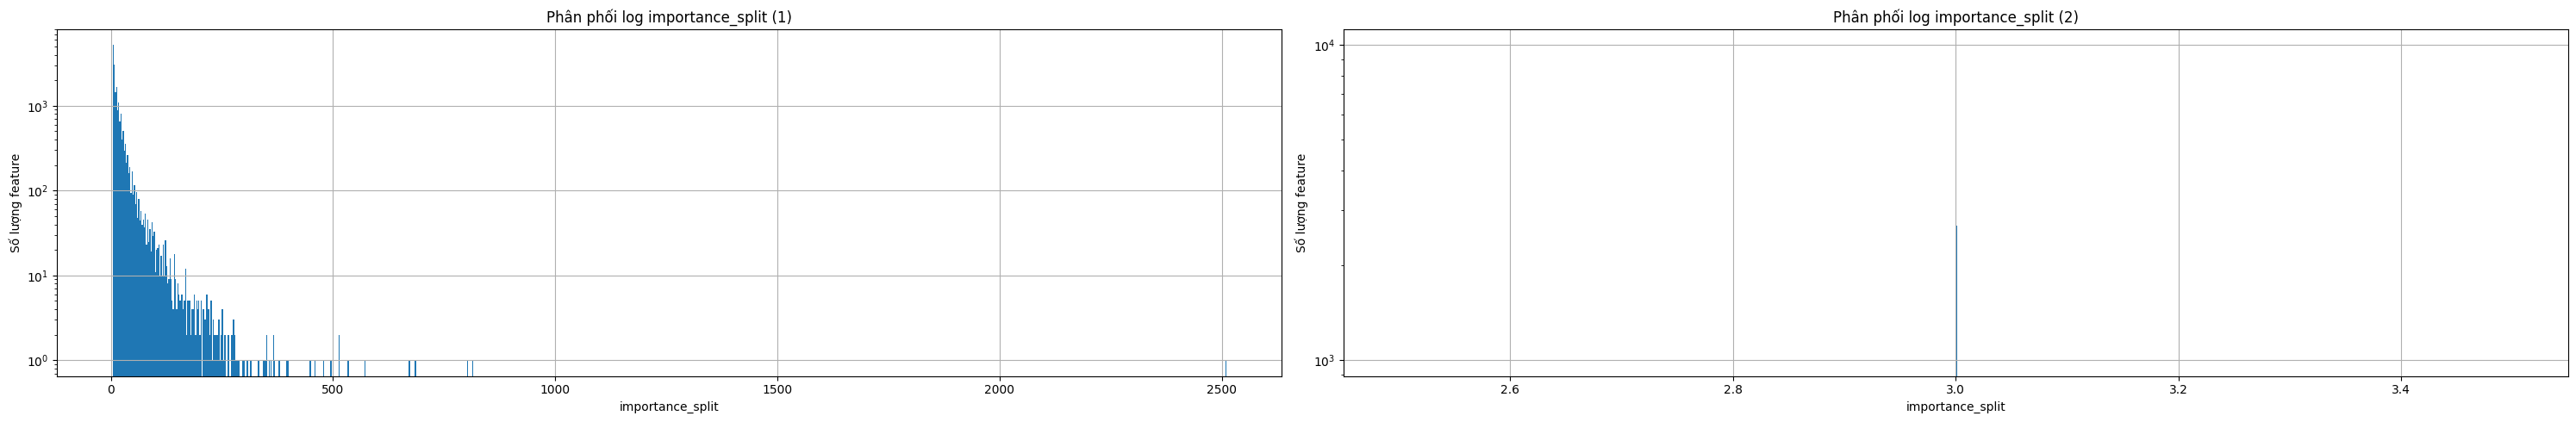

In [154]:
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 5))
plt.subplot(1, 2, 1)
lgbm_imp_sorted_1['importance_split'].hist(bins=1000, log=True)
plt.xlabel("importance_split")
plt.ylabel("Số lượng feature")
plt.title("Phân phối log importance_split (1)")

plt.subplot(1, 2, 2)
lgbm_imp_sorted_2['importance_split'].hist(bins=1000, log=True)
plt.xlabel("importance_split")
plt.ylabel("Số lượng feature")
plt.title("Phân phối log importance_split (2)")

plt.tight_layout()
plt.show()

### 55k+ meta features => [lọc split>2 & lấy phân vị 80%] => 19k features

In [168]:
lgbm_imp_sorted_1.reset_index(drop=True).to_csv(ROOT + "/.log/_used/lgbm_imp_f1_1.csv", index=False)

In [11]:
lgbm_imp_sorted_1 = pd.read_csv(ROOT + "/.log/_used/lgbm_imp_f1_1.csv")

In [12]:
features = lgbm_imp_sorted_1["feature"].tolist()

In [ ]:
feature_paths_f0 = [ROOT + "/data/feature/train/" + feature.strip() + ".f" for feature in features if feature.startswith("f0")]
feature_paths_f1 = [ROOT + "/data/feature/train/" + feature.strip() + ".f" for feature in features if feature.startswith("f1")]

n_thread=12 # cpu 6 cores 12 threads
chunk_size = n_thread * 50 # 40-50 là vừa đủ load 70 - 80% RAM, 80% CPU và GPU nhận được lượng data phù hợp tránh nghẽn cổ chai
chunks = [feature_paths_f1[i:i + chunk_size] for i in range(0, len(feature_paths_f1), chunk_size)]

target = pd.read_feather(utils.get_TARGET_path()).head(HEAD)
target.columns = ["TARGET"]

# multi thread
with ThreadPoolExecutor(max_workers=n_thread) as executor, \
    open(os.path.join(ROOT, f".log/_used/lgbm_imp_high_var_f12.csv"), "w", newline='') as f_selected:
    
    chunk=1
    writer = csv.writer(f_selected)
    writer.writerow(['chunk', 'feature', 'importance_gain', 'importance_split', 'auc_train', 'auc_valid'])

    futures = [executor.submit(read_feather_with_head, file_path) for file_path in feature_paths_f0]
    chunk_dfs = [future.result() for future in as_completed(futures)]
    X_f0 = pd.concat(chunk_dfs, axis=1)
    
    for file_paths in chunks:
        futures = [executor.submit(read_feather_with_head, file_path) for file_path in file_paths]
        chunk_dfs = [future.result() for future in as_completed(futures)]
        
        X = pd.concat(chunk_dfs, axis=1)
        X.columns = [sanitize_feature_name(name) for name in X.columns]
        X = pd.concat([X, X_f0], axis=1)
        
        X_train, X_val, y_train, y_val = train_test_split(
            X, target, test_size=0.2, random_state=SEED
        )

        dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=list(set(X_train.columns) & set(ALL_CAT)))
        dval = lgb.Dataset(X_val, label=y_val, categorical_feature=list(set(X_val.columns) & set(ALL_CAT)))

        model = lgb.train(param, dtrain, valid_sets=[dtrain, dval], valid_names=["train", "val"], num_boost_round=1000, callbacks=[lgb.log_evaluation(1000), lgb.early_stopping(100)])

        importance_gain = np.round(model.feature_importance(importance_type='gain'), 5)
        importance_split = model.feature_importance(importance_type='split')

        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        
        auc_train = np.round(roc_auc_score(y_train, y_pred_train), 5)
        auc_val = np.round(roc_auc_score(y_val, y_pred_val), 5)

        feature_names = X.columns
        csv_rows = []
        for i, feature_name in enumerate(feature_names):
            csv_rows.append([chunk, feature_name, importance_gain[i], importance_split[i], auc_train, auc_val])
        csv_rows.sort(key=lambda x: x[2], reverse=True)
        writer.writerows(csv_rows)
        print(len(csv_rows))
        chunk+=1

# round 2 - chú trọng hơn auc_valid vì đã có cải thiện

In [17]:
lgbm_imp = pd.read_csv(ROOT + "/.log/_used/lgbm_imp_high_var_f12.csv")

In [18]:
lgbm_imp = lgbm_imp[(lgbm_imp["importance_gain"]>0) & (lgbm_imp["importance_split"]>2)]

In [19]:
lgbm_imp_sorted = lgbm_imp.sort_values(["importance_gain", "importance_split"], ascending=[False, False])
lgbm_imp_sorted = lgbm_imp_sorted.drop_duplicates(subset='feature', keep='first')

In [20]:
lgbm_imp_sorted.sort_values(["auc_valid"], ascending=[False])["auc_valid"].unique()

# array([0.77195, 0.77122, 0.77047, 0.77024, 0.76991, 0.76971, 0.76941,
#        0.76901, 0.76892, 0.76891, 0.76889, 0.76888, 0.76868, 0.76863,
#        0.76855, 0.76848, 0.76806, 0.76791, 0.76789, 0.76778, 0.76721,
#        0.76703, 0.76702, 0.76699, 0.76679, 0.7666 , 0.7665 , 0.76635,
#        0.76629, 0.76611, 0.766  , 0.76588])

array([0.77195, 0.77122, 0.77047, 0.77024, 0.76991, 0.76971, 0.76941,
       0.76901, 0.76892, 0.76891, 0.76889, 0.76888, 0.76868, 0.76863,
       0.76855, 0.76848, 0.76806, 0.76791, 0.76789, 0.76778, 0.76721,
       0.76703, 0.76702, 0.76699, 0.76679, 0.7666 , 0.7665 , 0.76635,
       0.76629, 0.76611, 0.766  , 0.76588])

In [21]:
lgbm_imp_sorted_1 = pd.DataFrame()
lgbm_imp_sorted_2 = pd.DataFrame()

In [26]:
grter, smler = filter_by_threshold(lgbm_imp_sorted[lgbm_imp_sorted["auc_valid"]<0.76611], f = 'importance_split', th_min=30) # loại bỏ khá nhiều

lgbm_imp_sorted_1 = pd.concat([lgbm_imp_sorted_1, grter])
lgbm_imp_sorted_2 = pd.concat([lgbm_imp_sorted_2, smler])

In [27]:
grter, smler = filter_by_threshold(lgbm_imp_sorted[lgbm_imp_sorted["auc_valid"]>=0.76611], f = 'importance_split', th_min=3) # hầu như giữ nguyên, chỉ loại bỏ outliers

lgbm_imp_sorted_1 = pd.concat([lgbm_imp_sorted_1, grter])
lgbm_imp_sorted_2 = pd.concat([lgbm_imp_sorted_2, smler])

### 19k features => 17k+ features

In [29]:
lgbm_imp_sorted_1.sort_values(["auc_valid"], ascending=[False]).to_csv(ROOT + "/.log/_used/lgbm_imp_f1_2.csv", index=False)

In [30]:
lgbm_imp_sorted_1 = pd.read_csv(ROOT + "/.log/_used/lgbm_imp_f1_2.csv")
features = lgbm_imp_sorted_1["feature"].tolist()

In [ ]:
feature_paths_f0 = [ROOT + "/data/feature/train/" + feature.strip() + ".f" for feature in features if feature.startswith("f0")]
feature_paths_f1 = [ROOT + "/data/feature/train/" + feature.strip() + ".f" for feature in features if feature.startswith("f1")]

n_thread=12 # cpu 6 cores 12 threads
chunk_size = n_thread * 60 # 40-50 là vừa đủ load 70 - 80% RAM, 80% CPU và GPU nhận được lượng data phù hợp tránh nghẽn cổ chai
chunks = [feature_paths_f1[i:i + chunk_size] for i in range(0, len(feature_paths_f1), chunk_size)]

target = pd.read_feather(utils.get_TARGET_path()).head(HEAD)
target.columns = ["TARGET"]

# tunning tạm vì tăng số feature lên thành 1k+ cho 1 chunk
param = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,
    'max_depth': 7, # [6, 10, 15]
    'num_leaves': 32, # [31,33, 63...]
    'max_bin': 255,
    'min_child_weight': 12, # IMPORTANT [5, 10, 15, 20]
    'min_data_in_leaf': 250, # IMPORTANT [150, 200, 300]
    'reg_lambda': 1.5, # [0.5, 1, 2, 3] # L2 regularization term on weights.
    'reg_alpha': 1, # [0.5, 1, 2]  # L1 regularization term on weights.
    'colsample_bytree': 0.7,
    'subsample': 0.6, # 0.5
    # 'nthread': 12,
    'bagging_freq': 1,
    'verbose': -1,
    'seed': SEED,
    # thêm cấu hình cho GPU
    'device_type': 'gpu',
    'gpu_platform_id': 0,
    'gpu_device_id': 0,
}

# multi thread
with ThreadPoolExecutor(max_workers=n_thread) as executor, \
    open(os.path.join(ROOT, f".log/_used/lgbm_imp_high_var_f13.csv"), "w", newline='') as f_selected:
    
    chunk=1
    writer = csv.writer(f_selected)
    writer.writerow(['chunk', 'feature', 'importance_gain', 'importance_split', 'auc_train', 'auc_valid'])

    futures = [executor.submit(read_feather_with_head, file_path) for file_path in feature_paths_f0]
    chunk_dfs = [future.result() for future in as_completed(futures)]
    X_f0 = pd.concat(chunk_dfs, axis=1)
    
    for file_paths in chunks:
        futures = [executor.submit(read_feather_with_head, file_path) for file_path in file_paths]
        chunk_dfs = [future.result() for future in as_completed(futures)]
        
        X = pd.concat(chunk_dfs, axis=1)
        X.columns = [sanitize_feature_name(name) for name in X.columns]
        X = pd.concat([X, X_f0], axis=1)
        
        X_train, X_val, y_train, y_val = train_test_split(
            X, target, test_size=0.2, random_state=SEED
        )

        dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=list(set(X_train.columns) & set(ALL_CAT)))
        dval = lgb.Dataset(X_val, label=y_val, categorical_feature=list(set(X_val.columns) & set(ALL_CAT)))

        model = lgb.train(param, dtrain, valid_sets=[dtrain, dval], valid_names=["train", "val"], num_boost_round=1000, callbacks=[lgb.log_evaluation(1000), lgb.early_stopping(100)])

        importance_gain = np.round(model.feature_importance(importance_type='gain'), 5)
        importance_split = model.feature_importance(importance_type='split')

        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        
        auc_train = np.round(roc_auc_score(y_train, y_pred_train), 5)
        auc_val = np.round(roc_auc_score(y_val, y_pred_val), 5)

        feature_names = X.columns
        csv_rows = []
        for i, feature_name in enumerate(feature_names):
            csv_rows.append([chunk, feature_name, importance_gain[i], importance_split[i], auc_train, auc_val])
        csv_rows.sort(key=lambda x: x[2], reverse=True)
        writer.writerows(csv_rows)
        print(len(csv_rows))
        chunk+=1

# array([0.77195, 0.77122, 0.77047, 0.77024, 0.76991, 0.76971, 0.76941,
#        0.76901, 0.76892, 0.76891, 0.76889, 0.76888, 0.76868, 0.76863,
#        0.76855, 0.76848, 0.76806, 0.76791, 0.76789, 0.76778, 0.76721,
#        0.76703, 0.76702, 0.76699, 0.76679, 0.7666 , 0.7665 , 0.76635,
#        0.76629, 0.76611, 0.766  , 0.76588])

# round 3

In [73]:
lgbm_imp = pd.read_csv(ROOT + "/.log/_used/lgbm_imp_high_var_f13.csv")

In [74]:
lgbm_imp = lgbm_imp[(lgbm_imp["importance_gain"]>0) & (lgbm_imp["importance_split"]>2)]

In [75]:
lgbm_imp_sorted = lgbm_imp.sort_values(["importance_gain", "importance_split", "auc_valid"], ascending=[False, False, False])
lgbm_imp_sorted = lgbm_imp_sorted.drop_duplicates(subset='feature', keep='first')

In [71]:
lgbm_imp_sorted.sort_values(["auc_valid"], ascending=[False])["auc_valid"].unique()

# array([0.77225, 0.77222, 0.77114, 0.77035, 0.77018, 0.76932, 0.76925,
#        0.76917, 0.7691 , 0.76902, 0.76899, 0.76887, 0.76878, 0.76864,
#        0.76863, 0.76807, 0.7675 , 0.76732, 0.76721, 0.76718, 0.76713,
#        0.76695, 0.7663 ])

array([0.77225, 0.77222, 0.77114, 0.77035, 0.77018, 0.76932, 0.76925,
       0.76917, 0.7691 , 0.76902, 0.76899, 0.76887, 0.76878, 0.76864,
       0.76863, 0.76807, 0.7675 , 0.76732, 0.76721, 0.76718, 0.76713,
       0.76695, 0.7663 ])

In [352]:
lgbm_imp_sorted_1 = pd.DataFrame()
lgbm_imp_sorted_2 = pd.DataFrame()

In [353]:
limit=0.76917 # hợp lý

In [354]:
grter, smler = filter_by_threshold(lgbm_imp_sorted[lgbm_imp_sorted["auc_valid"]<limit], f = 'importance_split', th_min=9) # giảm so với round trước tránh mất thông tin

lgbm_imp_sorted_1 = pd.concat([lgbm_imp_sorted_1, grter])
lgbm_imp_sorted_2 = pd.concat([lgbm_imp_sorted_2, smler])

In [355]:
grter, smler = filter_by_threshold(lgbm_imp_sorted[lgbm_imp_sorted["auc_valid"]>=limit], f = 'importance_split', th_min=2) # hầu như giữ nguyên, chỉ loại bỏ outliers

lgbm_imp_sorted_1 = pd.concat([lgbm_imp_sorted_1, grter])
lgbm_imp_sorted_2 = pd.concat([lgbm_imp_sorted_2, smler])

### 17k+ features => 14k features

In [359]:
lgbm_imp_sorted_1.sort_values(["auc_valid"], ascending=[False]).to_csv(ROOT + "/.log/_used/lgbm_imp_f1_3.csv")

In [360]:
lgbm_imp_sorted_1 = pd.read_csv(ROOT + "/.log/_used/lgbm_imp_f1_3.csv")
features = lgbm_imp_sorted_1["feature"].tolist()

In [362]:
len(features)

14030

In [363]:
feature_paths_f0 = [ROOT + "/data/feature/train/" + feature.strip() + ".f" for feature in features if feature.startswith("f0")]
feature_paths_f1 = [ROOT + "/data/feature/train/" + feature.strip() + ".f" for feature in features if feature.startswith("f1")]

n_thread=12 # cpu 6 cores 12 threads
chunk_size = n_thread * 60 # 40-50 là vừa đủ load 70 - 80% RAM, 80% CPU và GPU nhận được lượng data phù hợp tránh nghẽn cổ chai
chunks = [feature_paths_f1[i:i + chunk_size] for i in range(0, len(feature_paths_f1), chunk_size)]

target = pd.read_feather(utils.get_TARGET_path()).head(HEAD)
target.columns = ["TARGET"]

# tunning tạm vì tăng số feature lên thành 1k+ cho 1 chunk
param = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.01,
    'max_depth': 7, # [6, 10, 15]
    'num_leaves': 32, # [31,33, 63...]
    'max_bin': 255,
    'min_child_weight': 12, # IMPORTANT [5, 10, 15, 20]
    'min_data_in_leaf': 250, # IMPORTANT [150, 200, 300]
    'reg_lambda': 1.5, # [0.5, 1, 2, 3] # L2 regularization term on weights.
    'reg_alpha': 1, # [0.5, 1, 2]  # L1 regularization term on weights.
    'colsample_bytree': 0.7,
    'subsample': 0.6, # 0.5
    # 'nthread': 12,
    'bagging_freq': 1,
    'verbose': -1,
    'seed': SEED,
    # thêm cấu hình cho GPU
    'device_type': 'gpu',
    'gpu_platform_id': 0,
    'gpu_device_id': 0,
}

# multi thread
with ThreadPoolExecutor(max_workers=n_thread) as executor, \
    open(os.path.join(ROOT, f".log/_used/lgbm_imp_high_var_f14.csv"), "w", newline='') as f_selected:
    
    chunk=1
    writer = csv.writer(f_selected)
    writer.writerow(['chunk', 'feature', 'importance_gain', 'importance_split', 'auc_train', 'auc_valid'])

    futures = [executor.submit(read_feather_with_head, file_path) for file_path in feature_paths_f0]
    chunk_dfs = [future.result() for future in as_completed(futures)]
    X_f0 = pd.concat(chunk_dfs, axis=1)
    
    for file_paths in chunks:
        futures = [executor.submit(read_feather_with_head, file_path) for file_path in file_paths]
        chunk_dfs = [future.result() for future in as_completed(futures)]
        
        X = pd.concat(chunk_dfs, axis=1)
        X.columns = [sanitize_feature_name(name) for name in X.columns]
        X = pd.concat([X, X_f0], axis=1)
        
        X_train, X_val, y_train, y_val = train_test_split(
            X, target, test_size=0.2, random_state=SEED
        )

        dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=list(set(X_train.columns) & set(ALL_CAT)))
        dval = lgb.Dataset(X_val, label=y_val, categorical_feature=list(set(X_val.columns) & set(ALL_CAT)))

        model = lgb.train(param, dtrain, valid_sets=[dtrain, dval], valid_names=["train", "val"], num_boost_round=1000, callbacks=[lgb.log_evaluation(1000), lgb.early_stopping(100)])

        importance_gain = np.round(model.feature_importance(importance_type='gain'), 5)
        importance_split = model.feature_importance(importance_type='split')

        y_pred_train = model.predict(X_train)
        y_pred_val = model.predict(X_val)
        
        auc_train = np.round(roc_auc_score(y_train, y_pred_train), 5)
        auc_val = np.round(roc_auc_score(y_val, y_pred_val), 5)

        feature_names = X.columns
        csv_rows = []
        for i, feature_name in enumerate(feature_names):
            csv_rows.append([chunk, feature_name, importance_gain[i], importance_split[i], auc_train, auc_val])
        csv_rows.sort(key=lambda x: x[2], reverse=True)
        writer.writerows(csv_rows)
        print(len(csv_rows))
        chunk+=1

# array([0.77195, 0.77122, 0.77047, 0.77024, 0.76991, 0.76971, 0.76941,
#        0.76901, 0.76892, 0.76891, 0.76889, 0.76888, 0.76868, 0.76863,
#        0.76855, 0.76848, 0.76806, 0.76791, 0.76789, 0.76778, 0.76721,
#        0.76703, 0.76702, 0.76699, 0.76679, 0.7666 , 0.7665 , 0.76635,
#        0.76629, 0.76611, 0.766  , 0.76588])

Training until validation scores don't improve for 100 rounds
[1000]	train's auc: 0.851399	val's auc: 0.771994
Did not meet early stopping. Best iteration is:
[999]	train's auc: 0.851312	val's auc: 0.772007
924
Training until validation scores don't improve for 100 rounds
[1000]	train's auc: 0.851541	val's auc: 0.77172
Did not meet early stopping. Best iteration is:
[995]	train's auc: 0.851201	val's auc: 0.771732
924
Training until validation scores don't improve for 100 rounds


KeyboardInterrupt: 

### Không có cải thiện valid, đã chạm trần thông tin của các feature, stop train. feature f1 là f1(ver)_3.csv